# Land Type Classification using Sentinel-2 Satellite Images
***

#### Some tests for GPU `tensorflow`

In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))


2.10.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.python.platform import build_info as tf_build_info
print("CUDA:", tf_build_info.build_info["cuda_version"])
print("cuDNN:", tf_build_info.build_info["cudnn_version"])

CUDA: 64_112
cuDNN: 64_8


#### Limited VRAM usage as CUDA allocate the whole entirety of VRAM

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration( gpus[0], [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=2048)] )
        print("[/] Limited GPU memory to 2 GB.")
    except RuntimeError as e:
        print(e)

[/] Limited GPU memory to 2 GB.


### Had to re-define `CategoricalFocalLoss` as it was missing in this old version of tensorflow
 - should have the same functionanlity

In [4]:
import tensorflow as tf
from tensorflow.keras.losses import Loss #type:ignore
from tensorflow.keras import backend as K #type:ignore

class CategoricalFocalLoss(Loss):
    """
    Categorical focal loss for one-hot labels.
    Usage:
        loss = CategoricalFocalLoss(gamma=2.0, alpha=0.25)
        model.compile(..., loss=loss, ...)
    """
    def __init__(self, gamma=2.0, alpha=0.25, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO, name="categorical_focal_loss"):
        super().__init__(reduction=reduction, name=name)
        self.gamma = float(gamma)
        self.alpha = float(alpha) if alpha is not None else None
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        """
        y_true: one-hot (batch, classes)
        y_pred: probabilities (softmax) or logits if from_logits=True
        """
        # If logits provided, convert to probabilities
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        # Clip to avoid log(0) and NaNs
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)

        # Compute cross-entropy per class
        cross_entropy = -y_true * K.log(y_pred)  # shape (batch, classes)

        # get p_t: the model probability for the true class per sample (elementwise y_true * y_pred)
        p_t = y_true * y_pred  # (batch, classes)

        # focal weighting: (1 - p_t)^gamma
        focal_factor = K.pow(1.0 - p_t, self.gamma)

        if self.alpha is not None:
            alpha_factor = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
            # For multiclass one-hot alpha factor reduces to alpha for true class; keep simple:
            alpha_factor = y_true * self.alpha  # only apply alpha to true class entries
        else:
            alpha_factor = 1.0

        # elementwise focal loss
        loss = alpha_factor * focal_factor * cross_entropy  # (batch, classes)

        # sum over classes then mean over batch
        loss = K.sum(loss, axis=-1)
        return K.mean(loss)

    def get_config(self):
        return {"gamma": self.gamma, "alpha": self.alpha, "from_logits": self.from_logits}


***
# Normal Code

In [5]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import csv

from tensorflow.keras.regularizers import l2 #type:ignore
from tensorflow.keras.optimizers import Adam, RMSprop, SGD #type:ignore
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.applications import EfficientNetB3 #type:ignore
from sklearn.utils.class_weight import compute_class_weight
#from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint #type:ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout #type:ignore
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, LeakyReLU, AveragePooling2D #type:ignore
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [6]:
from pathlib import Path
import os
import shutil
import random

#### Split data into folders

In [7]:
#script_path = os.path.dirname(os.path.abspath(__file__))
script_path = ""
original_folder = os.path.join(script_path, "EuroSAT_RGB")
base_folder = os.path.join(script_path, "EuroSAT_RGB_split")

In [8]:
def split_data():
    train_ratio = 0.7
    val_ratio = 0.15
    random_state = 42
    random.seed(random_state)

    for split in ["train", "validate", "test"]:
        os.makedirs(os.path.join(base_folder, split), exist_ok=True)
    
    for class_name in os.listdir(original_folder):
        class_path = os.path.join(original_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".tif"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        splits = {
            "train": images[:n_train],
            "validate": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            split_dir = os.path.join(base_folder, split_name, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_name in split_images:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(split_dir, img_name)
                shutil.copy(src, dst)

        print(f"{class_name}: {n_total} images split into train/val/test")

In [9]:
#split_data()


#### split_data() Output:
 - AnnualCrop: 3000 images split into train/val/test
 - Forest: 3000 images split into train/val/test
 - HerbaceousVegetation: 3000 images split into train/val/test
 - Highway: 2500 images split into train/val/test
 - Industrial: 2500 images split into train/val/test
 - Pasture: 2000 images split into train/val/test
 - PermanentCrop: 2500 images split into train/val/test
 - Residential: 3000 images split into train/val/test 
 - River: 2500 images split into train/val/test 
 - SeaLake: 3000 images split into train/val/test


In [10]:
train_dir = os.path.join(base_folder, "train")
val_dir = os.path.join(base_folder, "validate")
test_dir = os.path.join(base_folder, "test")

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.


In [12]:
results_file = 'random_search_results.csv'

completed_trials = 0
if os.path.exists(results_file):
    with open(results_file, 'r') as f:
        completed_trials = sum(1 for _ in f) - 1
print(f"Resuming from trial {completed_trials + 1}...")

if not os.path.exists(results_file):
    with open(results_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['trial', 'filters', 'conv_layers', 'dense_units', 'dropout', 'batch_norm', 'optimizer', 'lr', 'accuracy', 'precision', 'recall', 'f1_score', 'weighted_score','flattening_layers'])

Resuming from trial 78...


In [13]:
class_labels = train_generator.classes
class_weight_dict = dict(
    enumerate(
        compute_class_weight('balanced', classes=np.unique(class_labels), y=class_labels)
    )
)
class_weight_dict

{0: 0.9,
 1: 0.9,
 2: 0.9,
 3: 1.08,
 4: 1.08,
 5: 1.35,
 6: 1.08,
 7: 0.9,
 8: 1.08,
 9: 0.9}

***
### **Model (**`CNN`**) Training**

In [14]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

num_trials = 160
        
for k in range(completed_trials, num_trials):
    print(f"\n=== Trial {k+1}/{num_trials} ===")
    
    K.clear_session()
    
    callbacks = [
        ModelCheckpoint(f'checkpoints/best_model_{k}.h5', monitor='val_loss', save_best_only=True, verbose=0),
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
    ]
    
    params = { 
        'filters': random.choice([32, 64]), # 64
        'conv_layers': random.choice([2, 3, 4]), # 4
        'dense_units': random.choice([128, 256, 512]), # 256
        'dropout': round(random.uniform(0.3, 0.6), 2), # 0.4
        'batch_norm': random.choice([True, False]), # True
        'optimizer': random.choice(['adam', 'rmsprop', 'sgd']), # adam
        'lr': random.choice([1e-4, 5e-4, 1e-3, 5e-3]), # 1e-4
        'flattening_layers': ["flatten", "GAP2D"][1] 
    }

    model = Sequential()
    filters = params['filters']

    for i in range(params['conv_layers']):
        if i == 0:
            model.add(Conv2D(filters, (3,3), activation='relu', input_shape=(64, 64, 3)))
        else:
            model.add(Conv2D(filters, (3,3), activation='relu'))
        model.add(MaxPooling2D(2,2))
        if params['batch_norm']:
            model.add(BatchNormalization())
        filters *= 2  # Double filters each block
        
    if params["flattening_layers"] == "GAP2D":
        model.add(GlobalAveragePooling2D())
        model.add(Dense(params['dense_units'], activation='relu', kernel_regularizer=l2(0.001)))
    else:
        model.add(Flatten())
        model.add(Dense(params['dense_units'], activation='relu'))
        
    model.add(Dropout(params['dropout']))
    model.add(Dense(train_generator.num_classes, activation='softmax'))

    if params['optimizer'] == 'adam':
        opt = Adam(learning_rate=params['lr'])
    elif params['optimizer'] == 'rmsprop':
        opt = RMSprop(learning_rate=params['lr'])
    else:
        opt = SGD(learning_rate=params['lr'], momentum=0.9)

    model.compile(optimizer=opt, loss=CategoricalFocalLoss(gamma=2.0, alpha=0.25, from_logits=False), metrics=['accuracy'])

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=50,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=0
    )

    val_generator.reset()
    preds = model.predict(val_generator, verbose=0)
    y_true = val_generator.classes
    y_pred = np.argmax(preds, axis=1)

    acc = np.mean(y_true == y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    weighted_score = acc * precision * recall * f1

    with open(results_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            k + 1,
            params['filters'],
            params['conv_layers'],
            params['dense_units'],
            params['dropout'],
            params['batch_norm'],
            params['optimizer'],
            params['lr'],
            round(acc, 6),
            round(precision, 6), #type:ignore
            round(recall, 6), #type:ignore
            round(f1, 6), #type:ignore
            round(weighted_score, 6),
            params['flattening_layers']
        ])

    print(f"[/] Saved trial {k+1}: acc={acc:.4f}, f1={f1:.4f}, weighted={weighted_score:.6f}")


=== Trial 78/160 ===
[/] Saved trial 78: acc=0.8331, f1=0.8298, weighted=0.480998

=== Trial 79/160 ===
[/] Saved trial 79: acc=0.9440, f1=0.9440, weighted=0.795472

=== Trial 80/160 ===
[/] Saved trial 80: acc=0.6852, f1=0.6784, weighted=0.218252

=== Trial 81/160 ===
[/] Saved trial 81: acc=0.7886, f1=0.7862, weighted=0.384730

=== Trial 82/160 ===
[/] Saved trial 82: acc=0.7546, f1=0.7449, weighted=0.346659

=== Trial 83/160 ===
[/] Saved trial 83: acc=0.9254, f1=0.9253, weighted=0.734656

=== Trial 84/160 ===
[/] Saved trial 84: acc=0.5674, f1=0.5580, weighted=0.103412

=== Trial 85/160 ===
[/] Saved trial 85: acc=0.9035, f1=0.9030, weighted=0.668790

=== Trial 86/160 ===
[/] Saved trial 86: acc=0.8914, f1=0.8900, weighted=0.631337

=== Trial 87/160 ===
[/] Saved trial 87: acc=0.5911, f1=0.5849, weighted=0.122926

=== Trial 88/160 ===
[/] Saved trial 88: acc=0.5644, f1=0.5427, weighted=0.096580

=== Trial 89/160 ===
[/] Saved trial 89: acc=0.6835, f1=0.6795, weighted=0.217545

===

***
#### **Save Model**

In [15]:
model.save("SataliteClassification.h5")
#model = tf.keras.models.load_model("SataliteClassification.keras")

#### print used VRAM

In [16]:
gpus = tf.config.list_physical_devices('GPU')
details = tf.config.experimental.get_memory_info(gpus[0].name[17:])
print(f"GPU: {gpus[0].name}")
print(f"  Used VRAM: {details['current'] / 1024**2:.2f} MB")
print(f"  Peak VRAM: {details['peak'] / 1024**2:.2f} MB")

GPU: /physical_device:GPU:0
  Used VRAM: 19.56 MB
  Peak VRAM: 799.71 MB


#### **Model Test**
**Returns:**
 - Test Accuracy
 - Test Loss
 - y Predict

In [17]:
def evaluate_model(model, test_ds, class_names):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Results:\nAccuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

    preds = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    if hasattr(test_ds, 'labels'):
        y_true = test_ds.labels
    else:
        y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print('\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return test_acc, test_loss, y_pred


Test Results:
Accuracy: 0.8077 | Loss: 0.0741
127/127 [==============================] - 2s 15ms/step


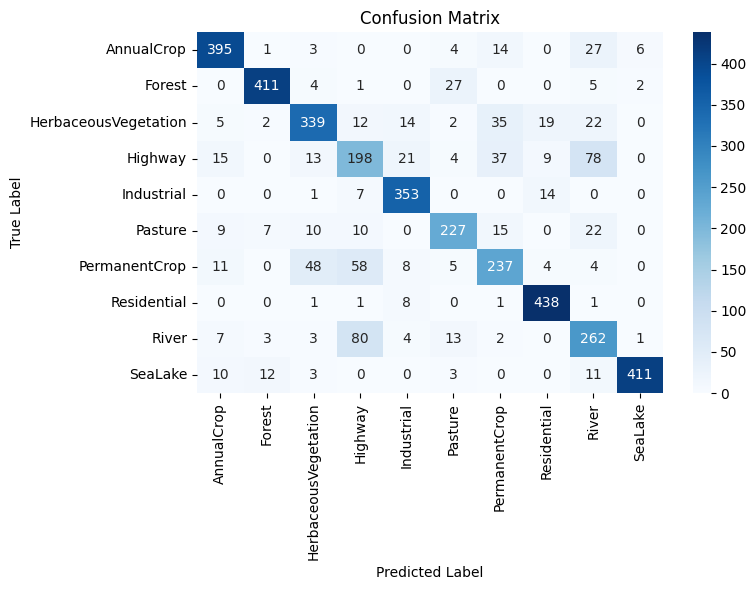


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.8739    0.8778    0.8758       450
              Forest     0.9427    0.9133    0.9278       450
HerbaceousVegetation     0.7976    0.7533    0.7749       450
             Highway     0.5395    0.5280    0.5337       375
          Industrial     0.8652    0.9413    0.9017       375
             Pasture     0.7965    0.7567    0.7761       300
       PermanentCrop     0.6950    0.6320    0.6620       375
         Residential     0.9050    0.9733    0.9379       450
               River     0.6065    0.6987    0.6493       375
             SeaLake     0.9786    0.9133    0.9448       450

            accuracy                         0.8077      4050
           macro avg     0.8000    0.7988    0.7984      4050
        weighted avg     0.8093    0.8077    0.8075      4050

Test Accuracy: 0.8077
Test Loss: 0.0741


In [18]:
test_acc, test_loss, y_pred = evaluate_model(model, test_generator, list(test_generator.class_indices.keys()))
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

***
#### **Plot Training Process**

In [19]:
def plot_training_curves(model, test_acc=0):
    acc = model.history['accuracy']
    val_acc = model.history['val_accuracy']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.axhline(y=test_acc, linestyle='--', color='green', label=f'Test Acc: {test_acc:.2f}')
    plt.title('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

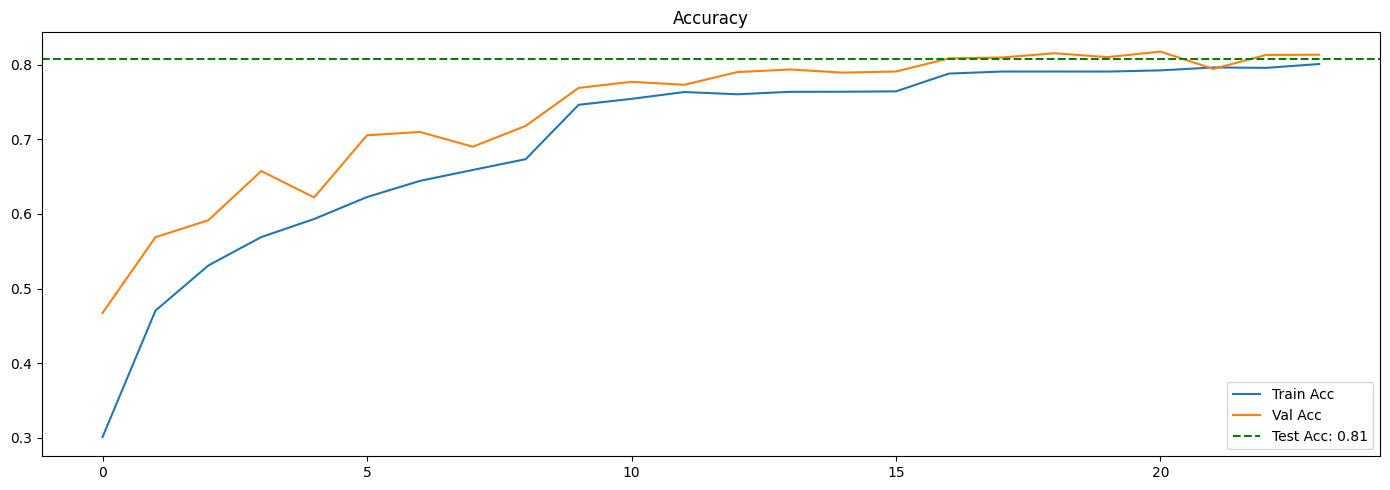

In [20]:
plot_training_curves(history, test_acc=test_acc)

***
#### Pick **Random** Image as test

1/1 [==============================] - 0s 262ms/step


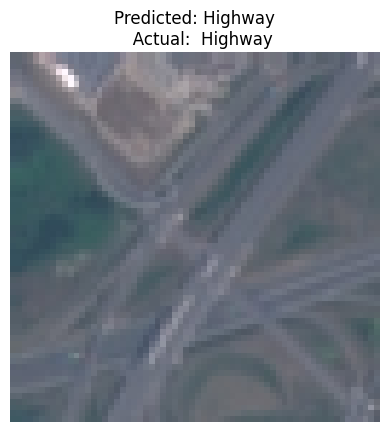

In [26]:
basefolder = os.path.join(script_path, "EuroSAT_RGB_split")
img_size = (64, 64)
class_names = list(test_generator.class_indices.keys())

all_image_paths = []

for split_dir in os.listdir(basefolder):
    split_path = os.path.join(basefolder, split_dir)
    if os.path.isdir(split_path):
        for class_dir in os.listdir(split_path):
            class_path = os.path.join(split_path, class_dir)
            if os.path.isdir(class_path):
                for fname in os.listdir(class_path):
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                        full_path = os.path.join(class_path, fname)
                        all_image_paths.append(full_path)


random_image_path = random.choice(all_image_paths)
image_type = random_image_path.split("\\")[-1].split("_")[0]

img = cv2.imread(random_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #type: ignore
img_resized = cv2.resize(img, img_size)
img_array = np.expand_dims(img_resized, axis=0) / 255.0  # normalize

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Predicted: {pred_class}\n   Actual:  {image_type}")
plt.axis('off')
plt.show()

***
#### Read `random_search_results.csv` file

In [27]:
import pandas as pd

df = pd.read_csv(results_file)
df_sorted = df.sort_values(by='weighted_score', ascending=False)
df_sorted.reset_index(drop=True, inplace=True)
df_sorted

,trial,filters,conv_layers,dense_units,dropout,batch_norm,optimizer,lr,accuracy,precision,recall,f1_score,weighted_score,flattening_layers
0,147,64,3,128,0.32,True,adam,0.0010,0.960247,0.960594,0.960247,0.960196,0.850483,GAP2D
1,137,64,3,128,0.46,True,rmsprop,0.0005,0.952840,0.952929,0.952840,0.952639,0.824192,GAP2D
2,126,32,3,128,0.33,True,adam,0.0010,0.945926,0.946351,0.945926,0.945805,0.800881,GAP2D
3,142,64,3,256,0.59,True,rmsprop,0.0001,0.944444,0.944842,0.944444,0.944300,0.795833,GAP2D
4,79,64,3,256,0.56,True,rmsprop,0.0005,0.943951,0.945732,0.943951,0.943971,0.795472,GAP2D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,50,32,3,512,0.52,True,adam,0.0050,0.217284,0.066192,0.217284,0.099410,0.000311,flatten
156,33,32,2,256,0.52,True,adam,0.0050,0.185679,0.055198,0.185679,0.080039,0.000152,flatten
157,24,32,3,256,0.53,True,adam,0.0050,0.111111,0.012346,0.111111,0.022222,0.000003,flatten
158,76,64,2,512,0.54,False,rmsprop,0.0050,0.111111,0.012346,0.111111,0.022222,0.000003,flatten
